# Learning the Susceptible-Infected-Removed (SIR) Model

The goal of this project is to use machine learning to deduce the deterministic form of the classic SIR epidemic model from a large collection of synthetic stochastic simulations.


In [48]:
!pip install torch numpy matplotlib scipy sympy scikit-learn tqdm -q

In [49]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import sympy as sp
from tqdm import tqdm

warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cpu
PyTorch : 2.10.0+cpu


---
---
## 1. The SIR Model

$$\frac{dS}{dt} = -\frac{\beta S I}{N}, \qquad \frac{dI}{dt} = \frac{\beta S I}{N} - \gamma I, \qquad \frac{dR}{dt} = \gamma I$$

$\beta$: transmission rate, $\gamma$: recovery rate, $R_0 = \beta/\gamma$. Epidemic grows when $R_0 > 1$.

We simulate the stochastic version (Gillespie algorithm) and average over many runs — that mean trajectory is what the network learns to predict.

In [50]:
def simulate_deterministic_sir(beta, gamma, S0, I0, N, t_max, n_points=100):
    R0_init = N - S0 - I0

    def sir_odes(t, y):
        S, I, R = y
        dS = -beta * S * I / N
        dI =  beta * S * I / N - gamma * I
        dR =  gamma * I
        return [dS, dI, dR]

    t_eval = np.linspace(0, t_max, n_points)
    sol = solve_ivp(sir_odes, [0, t_max], [S0, I0, R0_init],
                    t_eval=t_eval, method='RK45', dense_output=True)
    return sol.t, sol.y[0]/N, sol.y[1]/N, sol.y[2]/N


def simulate_stochastic_sir(beta, gamma, S0, I0, N, t_max, n_points=100):
    S, I, R = S0, I0, N - S0 - I0
    t = 0.0
    t_series = [t]
    S_series, I_series, R_series = [S], [I], [R]

    while t < t_max and I > 0:
        rate_infection = beta * S * I / N
        rate_recovery  = gamma * I
        total_rate     = rate_infection + rate_recovery

        if total_rate == 0:
            break

        dt = np.random.exponential(1.0 / total_rate)
        t += dt

        if t > t_max:
            break

        if np.random.uniform() < rate_infection / total_rate:
            S -= 1; I += 1
        else:
            I -= 1; R += 1

        t_series.append(t)
        S_series.append(S)
        I_series.append(I)
        R_series.append(R)

    if t_series[-1] < t_max:
        t_series.append(t_max)
        S_series.append(S_series[-1])
        I_series.append(0)
        R_series.append(R_series[-1])

    t_grid = np.linspace(0, t_max, n_points)
    S_grid = np.interp(t_grid, t_series, S_series) / N
    I_grid = np.interp(t_grid, t_series, I_series) / N
    R_grid = np.interp(t_grid, t_series, R_series) / N

    return t_grid, S_grid, I_grid, R_grid

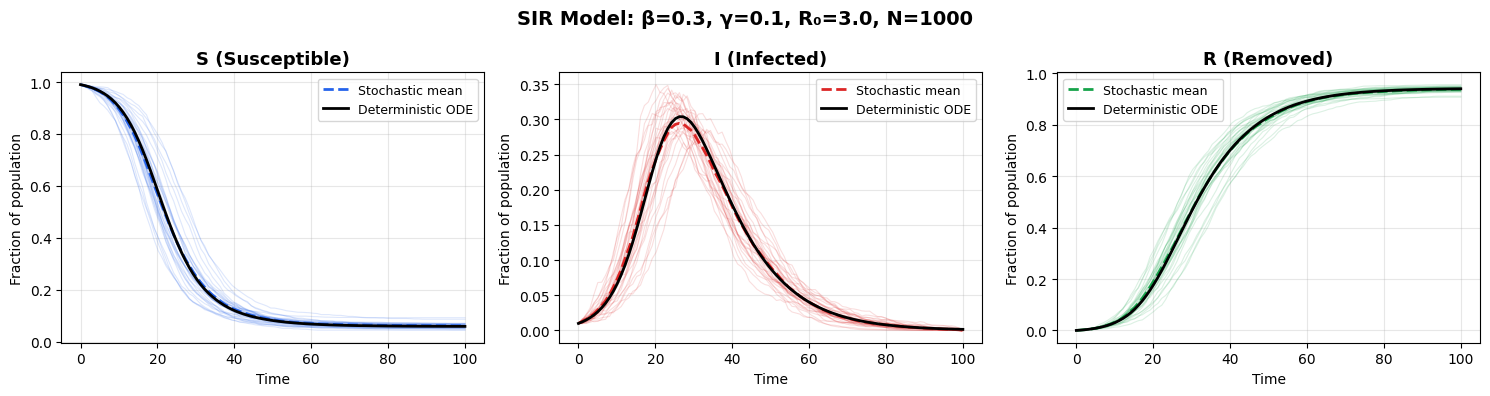

In [51]:
N = 1000
S0, I0 = 990, 10
beta, gamma = 0.3, 0.1
T_MAX = 100
N_PTS = 100
N_RUNS = 30

t_det, S_det, I_det, R_det = simulate_deterministic_sir(beta, gamma, S0, I0, N, T_MAX, N_PTS)

stoch_runs = [simulate_stochastic_sir(beta, gamma, S0, I0, N, T_MAX, N_PTS)
              for _ in range(N_RUNS)]

S_stoch = np.array([r[1] for r in stoch_runs])
I_stoch = np.array([r[2] for r in stoch_runs])
R_stoch = np.array([r[3] for r in stoch_runs])
t_grid  = stoch_runs[0][0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels     = ['S (Susceptible)', 'I (Infected)', 'R (Removed)']
det_data   = [S_det, I_det, R_det]
stoch_data = [S_stoch, I_stoch, R_stoch]
colors     = ['#2563EB', '#DC2626', '#16A34A']

for ax, label, det, stoch, col in zip(axes, labels, det_data, stoch_data, colors):
    for run in stoch:
        ax.plot(t_grid, run, alpha=0.15, color=col, linewidth=0.8)
    ax.plot(t_grid, stoch.mean(axis=0), color=col, linewidth=2, linestyle='--', label='Stochastic mean')
    ax.plot(t_det, det, color='black', linewidth=2, label='Deterministic ODE')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Fraction of population')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'SIR Model: β={beta}, γ={gamma}, R₀={beta/gamma:.1f}, N={N}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sir_stochastic_vs_deterministic.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Building the Dataset

Sample (β, γ) pairs uniformly, run 25 stochastic replicas per point, average them. Only keep runs where $R_0 > 1.05$. The deterministic ODE solution is stored alongside for comparison.

In [52]:
def generate_dataset(n_params=500, n_replicas=20, n_points=50,
                     N=1000, S0=990, I0=10, t_max=100,
                     beta_range=(0.1, 0.5), gamma_range=(0.05, 0.3)):
    params_list, mean_traj_list, det_traj_list = [], [], []
    t_grid = np.linspace(0, t_max, n_points)

    for _ in tqdm(range(n_params), desc='Generating dataset'):
        beta  = np.random.uniform(*beta_range)
        gamma = np.random.uniform(*gamma_range)

        if beta / gamma < 1.05:
            continue

        S_runs, I_runs, R_runs = [], [], []
        for _ in range(n_replicas):
            _, S, I, R = simulate_stochastic_sir(beta, gamma, S0, I0, N, t_max, n_points)
            S_runs.append(S); I_runs.append(I); R_runs.append(R)

        mean_SIR = np.stack([
            np.mean(S_runs, axis=0),
            np.mean(I_runs, axis=0),
            np.mean(R_runs, axis=0)
        ], axis=-1)

        _, S_d, I_d, R_d = simulate_deterministic_sir(beta, gamma, S0, I0, N, t_max, n_points)
        det_SIR = np.stack([S_d, I_d, R_d], axis=-1)

        params_list.append([beta, gamma])
        mean_traj_list.append(mean_SIR)
        det_traj_list.append(det_SIR)

    params     = np.array(params_list,    dtype=np.float32)
    mean_trajs = np.array(mean_traj_list, dtype=np.float32)
    det_trajs  = np.array(det_traj_list,  dtype=np.float32)

    return params, t_grid.astype(np.float32), mean_trajs, det_trajs


params, t_grid, mean_trajs, det_trajs = generate_dataset(
    n_params=600, n_replicas=25, n_points=50)

Generating dataset: 100%|██████████| 600/600 [01:48<00:00,  5.52it/s]


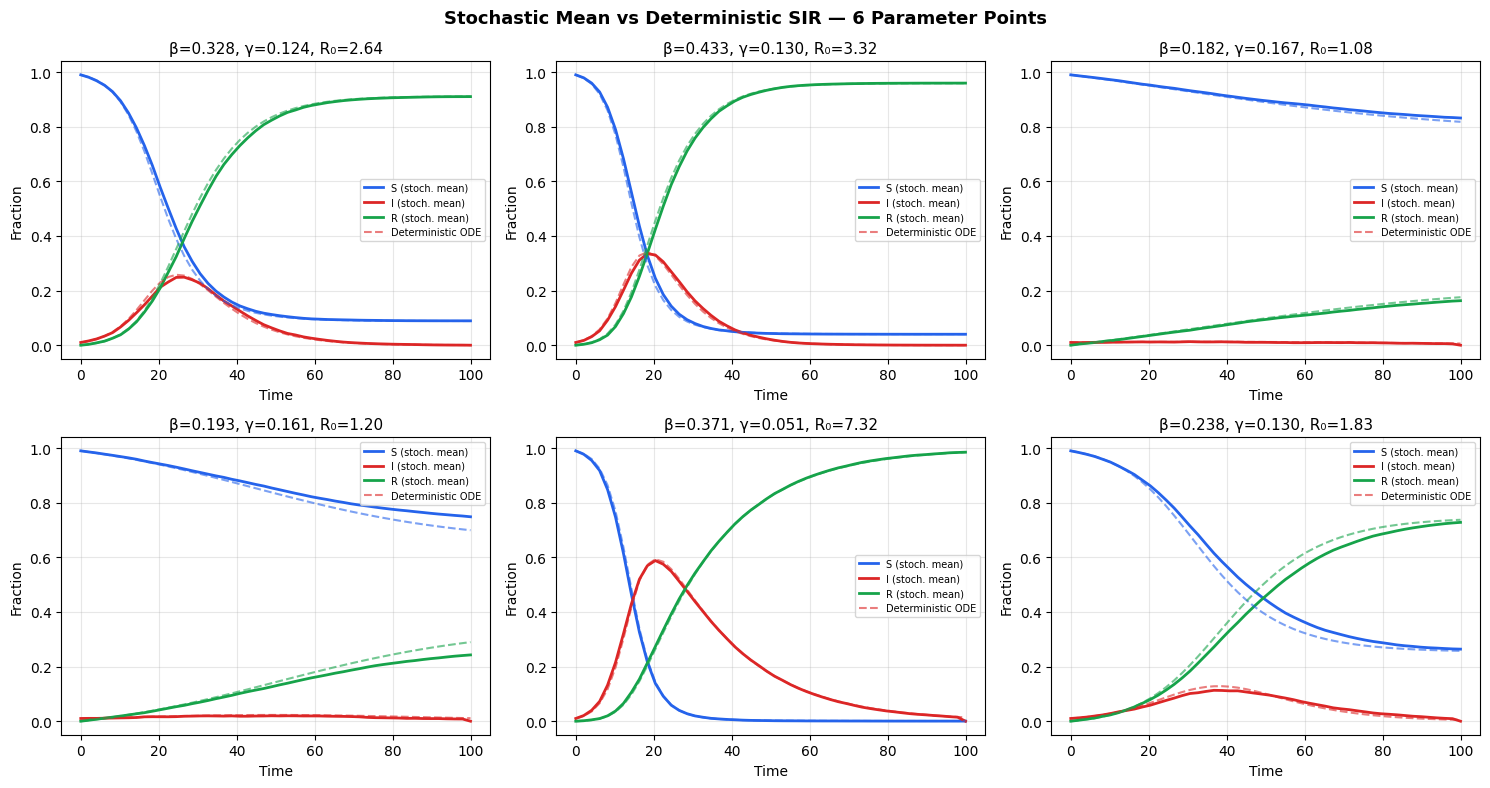

In [53]:
idxs = np.random.choice(len(params), 6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, idx in zip(axes.flat, idxs):
    b, g = params[idx]
    ax.plot(t_grid, mean_trajs[idx, :, 0], '#2563EB', lw=2, label='S (stoch. mean)')
    ax.plot(t_grid, mean_trajs[idx, :, 1], '#DC2626', lw=2, label='I (stoch. mean)')
    ax.plot(t_grid, mean_trajs[idx, :, 2], '#16A34A', lw=2, label='R (stoch. mean)')
    ax.plot(t_grid, det_trajs[idx, :, 0],  '#2563EB', lw=1.5, ls='--', alpha=0.6)
    ax.plot(t_grid, det_trajs[idx, :, 1],  '#DC2626', lw=1.5, ls='--', alpha=0.6, label='Deterministic ODE')
    ax.plot(t_grid, det_trajs[idx, :, 2],  '#16A34A', lw=1.5, ls='--', alpha=0.6)
    ax.set_title(f'β={b:.3f}, γ={g:.3f}, R₀={b/g:.2f}', fontsize=11)
    ax.set_xlabel('Time')
    ax.set_ylabel('Fraction')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Stochastic Mean vs Deterministic SIR — 6 Parameter Points', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sir_dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Neural Network

MLP mapping (β, γ, t/T) → (S, I, R). Softmax output enforces $S + I + R = 1$ by construction. No ODE knowledge baked in — the physics recovery happens in sections 4–6.


In [54]:
class SIRDataset(Dataset):
    def __init__(self, params, t_grid, mean_trajs, t_max=100.0):
        n_params, n_points, _ = mean_trajs.shape

        betas  = np.repeat(params[:, 0], n_points)
        gammas = np.repeat(params[:, 1], n_points)
        times  = np.tile(t_grid / t_max, n_params)

        X = np.column_stack([betas, gammas, times])
        y = mean_trajs.reshape(-1, 3)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


class SIRNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 64),
            nn.SiLU(),
            nn.Linear(64, 3)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return F.softmax(self.net(x), dim=-1)


dataset = SIRDataset(params, t_grid, mean_trajs)
n_val   = int(0.15 * len(dataset))
n_train = len(dataset) - n_val

train_ds, val_ds = random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42))

pin_mem = (DEVICE == 'cuda')
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,  num_workers=0, pin_memory=pin_mem)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0, pin_memory=pin_mem)

model     = SIRNet(hidden=128).to(DEVICE)
optimizer = Adam(model.parameters(), lr=3e-3, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=100)

print(f'Train : {n_train:,} samples')
print(f'Val   : {n_val:,} samples')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Train : 19,975 samples
Val   : 3,525 samples
Params: 58,499


In [55]:
#Trainig
EPOCHS = 100
train_losses, val_losses = [], []
best_val = float('inf')

for epoch in range(1, EPOCHS + 1):

    model.train()
    tl = 0.0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = F.mse_loss(model(X), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item() * X.size(0)
    tl /= n_train

    model.eval()
    vl = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            vl += F.mse_loss(model(X), y).item() * X.size(0)
    vl /= n_val

    scheduler.step()
    train_losses.append(tl)
    val_losses.append(vl)

    if vl < best_val:
        best_val = vl
        torch.save(model.state_dict(), 'sir_model_best.pth')

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train={tl:.6f}  val={vl:.6f}')

print(f'\nBest val MSE: {best_val:.6f}')

Epoch   1/100  train=0.054277  val=0.028383
Epoch  10/100  train=0.000462  val=0.000428
Epoch  20/100  train=0.000385  val=0.000309
Epoch  30/100  train=0.000292  val=0.000788
Epoch  40/100  train=0.000328  val=0.000324
Epoch  50/100  train=0.000198  val=0.000292
Epoch  60/100  train=0.000199  val=0.000208
Epoch  70/100  train=0.000193  val=0.000195
Epoch  80/100  train=0.000184  val=0.000174
Epoch  90/100  train=0.000179  val=0.000173
Epoch 100/100  train=0.000173  val=0.000172

Best val MSE: 0.000172


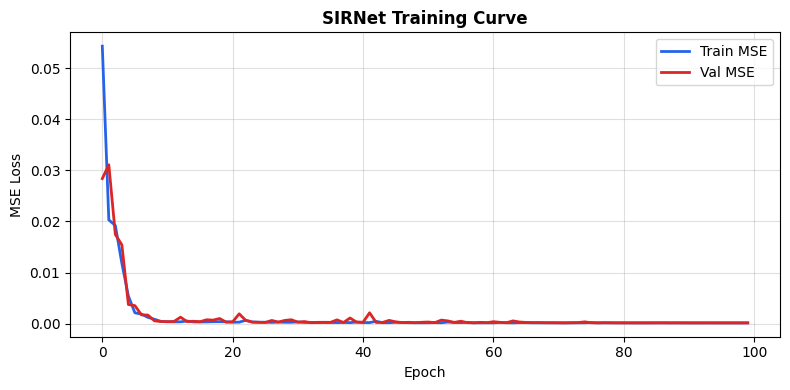

In [56]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, '#2563EB', lw=2, label='Train MSE')
plt.plot(val_losses,   '#DC2626', lw=2, label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('SIRNet Training Curve', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('sirnet_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
model.load_state_dict(torch.load('sir_model_best.pth', map_location=DEVICE, weights_only=True))
model.eval()

T_MAX = 100.0

def predict_trajectory(model, beta, gamma, t_grid, t_max=T_MAX):
    n = len(t_grid)
    inputs = np.column_stack([np.full(n, beta), np.full(n, gamma), t_grid / t_max])
    with torch.no_grad():
        pred = model(torch.tensor(inputs, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    return pred[:, 0], pred[:, 1], pred[:, 2]

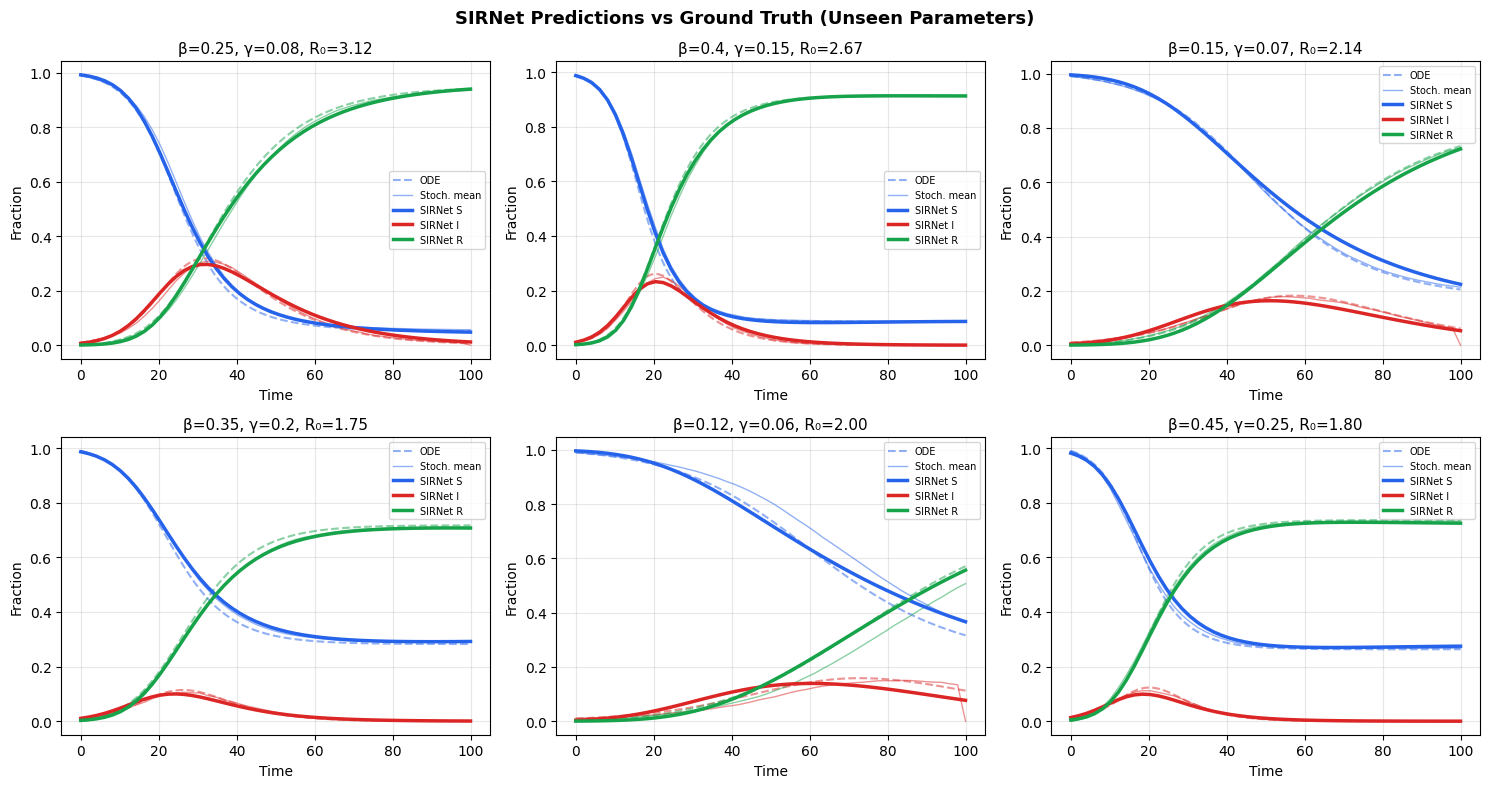

In [58]:
test_params = [
    (0.25, 0.08), (0.40, 0.15), (0.15, 0.07),
    (0.35, 0.20), (0.12, 0.06), (0.45, 0.25)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (b, g) in zip(axes.flat, test_params):
    t_det, S_d, I_d, R_d = simulate_deterministic_sir(b, g, 990, 10, 1000, T_MAX, 100)

    runs = [simulate_stochastic_sir(b, g, 990, 10, 1000, T_MAX, 50) for _ in range(20)]
    t_s = runs[0][0]
    S_m = np.mean([r[1] for r in runs], axis=0)
    I_m = np.mean([r[2] for r in runs], axis=0)
    R_m = np.mean([r[3] for r in runs], axis=0)

    S_p, I_p, R_p = predict_trajectory(model, b, g, t_s)

    ax.plot(t_det, S_d, '#2563EB', lw=1.5, ls='--', alpha=0.5, label='ODE')
    ax.plot(t_det, I_d, '#DC2626', lw=1.5, ls='--', alpha=0.5)
    ax.plot(t_det, R_d, '#16A34A', lw=1.5, ls='--', alpha=0.5)
    ax.plot(t_s, S_m, '#2563EB', lw=1, alpha=0.5, label='Stoch. mean')
    ax.plot(t_s, I_m, '#DC2626', lw=1, alpha=0.5)
    ax.plot(t_s, R_m, '#16A34A', lw=1, alpha=0.5)
    ax.plot(t_s, S_p, '#2563EB', lw=2.5, label='SIRNet S')
    ax.plot(t_s, I_p, '#DC2626', lw=2.5, label='SIRNet I')
    ax.plot(t_s, R_p, '#16A34A', lw=2.5, label='SIRNet R')
    ax.set_title(f'β={b}, γ={g}, R₀={b/g:.2f}', fontsize=11)
    ax.set_xlabel('Time')
    ax.set_ylabel('Fraction')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('SIRNet Predictions vs Ground Truth (Unseen Parameters)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sirnet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
all_true, all_pred = [], []
model.eval()
with torch.no_grad():
    for X, y in val_loader:
        all_pred.append(model(X.to(DEVICE)).cpu().numpy())
        all_true.append(y.numpy())

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print(f'{"Compartment":<12} {"MSE":<12} {"MAE":<12} {"R²":<10}')
print('-' * 48)
for i, name in enumerate(['S', 'I', 'R']):
    mse = np.mean((all_true[:, i] - all_pred[:, i])**2)
    mae = np.mean(np.abs(all_true[:, i] - all_pred[:, i]))
    r2  = r2_score(all_true[:, i], all_pred[:, i])
    print(f'{name:<12} {mse:<12.6f} {mae:<12.6f} {r2:<10.4f}')

print(f'\nOverall MSE : {np.mean((all_true - all_pred)**2):.6f}')
print(f'Overall R²  : {r2_score(all_true, all_pred):.4f}')

Compartment  MSE          MAE          R²        
------------------------------------------------
S            0.000202     0.010177     0.9983    
I            0.000099     0.006863     0.9891    
R            0.000216     0.010841     0.9982    

Overall MSE : 0.000172
Overall R²  : 0.9952


---
## 4. Auto-Differentiation

Since $t_{norm} = t/T$ is a network input, autograd gives us exact $dS/dt$, $dI/dt$, $dR/dt$

— no finite differences needed.

In [60]:
def compute_sir_derivatives(model, beta_val, gamma_val, t_points, t_max=100.0):
    n = len(t_points)

    t_norm = torch.tensor(t_points / t_max, dtype=torch.float32,
                          requires_grad=True).to(DEVICE)

    # torch.cat keeps t_norm in the graph so gradients flow back to it
    beta_col  = torch.full((n, 1), beta_val,  dtype=torch.float32).to(DEVICE)
    gamma_col = torch.full((n, 1), gamma_val, dtype=torch.float32).to(DEVICE)
    x = torch.cat([beta_col, gamma_col, t_norm.unsqueeze(1)], dim=1)

    SIR = model(x)
    S, I, R = SIR[:, 0], SIR[:, 1], SIR[:, 2]

    ones = torch.ones(n, device=DEVICE)
    # retain_graph=True keeps the graph alive for the next grad call
    dSdt = torch.autograd.grad(S, t_norm, grad_outputs=ones, retain_graph=True)[0] / t_max
    dIdt = torch.autograd.grad(I, t_norm, grad_outputs=ones, retain_graph=True)[0] / t_max
    dRdt = torch.autograd.grad(R, t_norm, grad_outputs=ones)[0] / t_max

    return (
        S.detach().cpu().numpy(),
        I.detach().cpu().numpy(),
        R.detach().cpu().numpy(),
        dSdt.detach().cpu().numpy(),
        dIdt.detach().cpu().numpy(),
        dRdt.detach().cpu().numpy()
    )


S_ex, I_ex, R_ex, dSdt_ex, dIdt_ex, dRdt_ex = compute_sir_derivatives(model, 0.3, 0.1, t_grid)

peak_idx = np.argmax(I_ex)
print(f'At peak infection (t={t_grid[peak_idx]:.1f}):')
print(f'  S={S_ex[peak_idx]:.3f}, I={I_ex[peak_idx]:.3f}, R={R_ex[peak_idx]:.3f}')
print(f'  dS/dt={dSdt_ex[peak_idx]:.4f}  (expected ≈ {-0.3*S_ex[peak_idx]*I_ex[peak_idx]:.4f})')
print(f'  dR/dt={dRdt_ex[peak_idx]:.4f}  (expected ≈ {0.1*I_ex[peak_idx]:.4f})')

At peak infection (t=26.5):
  S=0.366, I=0.284, R=0.350
  dS/dt=-0.0303  (expected ≈ -0.0312)
  dR/dt=0.0293  (expected ≈ 0.0284)


## 5. Parameter Recovery

Inverting the SIR equations gives $\beta = -\frac{dS/dt}{SI}$ and $\gamma = \frac{dR/dt}{I}$. We take the median over active-epidemic time points to avoid noise near the boundaries.

In [61]:
def recover_parameters_from_autodiff(model, beta_true, gamma_true, t_grid, t_max=100.0):
    S, I, R, dSdt, dIdt, dRdt = compute_sir_derivatives(
        model, beta_true, gamma_true, t_grid, t_max)

    mask = (I > 0.01) & (S > 0.01)

    beta_est  = np.median(-dSdt[mask] / (S[mask] * I[mask]))
    gamma_est = np.median(dRdt[mask] / I[mask])

    return float(beta_est), float(gamma_est)


test_cases = [
    (0.30, 0.10), (0.25, 0.08), (0.40, 0.15),
    (0.20, 0.07), (0.35, 0.12), (0.45, 0.20)
]

print(f'{"β_true":<10} {"γ_true":<10} {"β_est":<10} {"γ_est":<10} '
      f'{"β_err%":<10} {"γ_err%":<10} {"R₀_true":<10} {"R₀_est":<10}')
print('-' * 80)

for beta_t, gamma_t in test_cases:
    beta_e, gamma_e = recover_parameters_from_autodiff(model, beta_t, gamma_t, t_grid)
    b_err = abs(beta_e  - beta_t)  / beta_t  * 100
    g_err = abs(gamma_e - gamma_t) / gamma_t * 100
    print(f'{beta_t:<10.3f} {gamma_t:<10.3f} {beta_e:<10.3f} {gamma_e:<10.3f} '
          f'{b_err:<10.1f} {g_err:<10.1f} {beta_t/gamma_t:<10.2f} {beta_e/gamma_e:<10.2f}')

β_true     γ_true     β_est      γ_est      β_err%     γ_err%     R₀_true    R₀_est    
--------------------------------------------------------------------------------
0.300      0.100      0.290      0.087      3.5        13.2       3.00       3.34      
0.250      0.080      0.253      0.074      1.1        7.7        3.12       3.42      
0.400      0.150      0.375      0.128      6.3        14.8       2.67       2.93      
0.200      0.070      0.209      0.070      4.3        0.6        2.86       3.00      
0.350      0.120      0.322      0.102      7.9        14.7       2.92       3.15      
0.450      0.200      0.453      0.185      0.8        7.5        2.25       2.45      


## 6. Symbolic Regression

Beyond recovering parameter values, the deeper question is: **can we rediscover the functional form of the ODEs from data alone, without ever telling the model they follow a bilinear structure?**

The approach is SINDy-style sparse regression. We collect (S, I, R) states and their auto-differentiated time derivatives across 80 different (β, γ) points, build a library of candidate symbolic terms [$S$, $I$, $R$, $SI$, $SR$, $IR$, $S^2$, $I^2$, $R^2$, ...], and fit a LASSO model to each derivative. The L1 penalty drives most coefficients to zero — only the terms that genuinely explain the dynamics survive.

If the network learned the SIR dynamics faithfully, LASSO should recover exactly $SI$ for $dS/dt$ and $dI/dt$, and exactly $I$ for $dR/dt$.

In [62]:
def build_feature_library(S, I, R):
    features = np.column_stack([
        S,     I,     R,
        S*I,   S*R,   I*R,
        S**2,  I**2,  R**2,
        S*I*R, S**2*I, S*I**2
    ])
    names = ['S', 'I', 'R', 'SI', 'SR', 'IR', 'S²', 'I²', 'R²', 'SIR', 'S²I', 'SI²']
    return features, names


def symbolic_regression_sir(model, params_subset, t_grid, t_max=100.0, lasso_alpha=5e-4):
    all_S, all_I, all_R = [], [], []
    all_dSdt, all_dIdt, all_dRdt = [], [], []

    for beta_v, gamma_v in tqdm(params_subset, desc='Computing derivatives'):
        S, I, R, dSdt, dIdt, dRdt = compute_sir_derivatives(
            model, float(beta_v), float(gamma_v), t_grid, t_max)
        mask = I > 0.01
        all_S.append(S[mask]);       all_I.append(I[mask]);       all_R.append(R[mask])
        all_dSdt.append(dSdt[mask]); all_dIdt.append(dIdt[mask]); all_dRdt.append(dRdt[mask])

    S_all    = np.concatenate(all_S)
    I_all    = np.concatenate(all_I)
    R_all    = np.concatenate(all_R)
    dSdt_all = np.concatenate(all_dSdt)
    dIdt_all = np.concatenate(all_dIdt)
    dRdt_all = np.concatenate(all_dRdt)

    Phi, names = build_feature_library(S_all, I_all, R_all)

    # standardize so LASSO penalizes all terms on the same scale
    scaler = StandardScaler()
    Phi_scaled = scaler.fit_transform(Phi)

    results = {}
    for target, dname in [(dSdt_all, 'dS/dt'), (dIdt_all, 'dI/dt'), (dRdt_all, 'dR/dt')]:
        lasso = Lasso(alpha=lasso_alpha, fit_intercept=False, max_iter=10_000)
        lasso.fit(Phi_scaled, target)
        results[dname] = dict(zip(names, lasso.coef_ / scaler.scale_))

    return results


subset_idx = np.random.choice(len(params), min(80, len(params)), replace=False)
sym_results = symbolic_regression_sir(model, params[subset_idx], t_grid)

Computing derivatives: 100%|██████████| 80/80 [00:00<00:00, 451.24it/s]


In [63]:
def format_equation(derivative_name, coeffs, threshold=0.005):
    terms = [f'({coef:+.4f})·{name}'
             for name, coef in coeffs.items() if abs(coef) > threshold]
    if not terms:
        return f'{derivative_name} ≈ 0'
    return f'{derivative_name} ≈ ' + ' '.join(terms)


print('True SIR equations:')
print('  dS/dt = -β·SI')
print('  dI/dt = +β·SI - γ·I')
print('  dR/dt = +γ·I')
print()
print('Discovered:')
for deriv, coeffs in sym_results.items():
    print(f'  {format_equation(deriv, coeffs)}')

print()
print(f'{"Equation":<10} {"Term":<10} {"Coefficient":<16} {"Sign correct?"}')
print('-' * 50)

checks = [
    ('dS/dt', 'SI', 'negative', sym_results['dS/dt'].get('SI', 0.0)),
    ('dI/dt', 'SI', 'positive', sym_results['dI/dt'].get('SI', 0.0)),
    ('dI/dt', 'I',  'negative', sym_results['dI/dt'].get('I',  0.0)),
    ('dR/dt', 'I',  'positive', sym_results['dR/dt'].get('I',  0.0)),
]

for eq, term, expected_sign, coef in checks:
    correct = '✓' if (expected_sign == 'negative' and coef < -0.005) or \
                     (expected_sign == 'positive' and coef >  0.005) else '✗'
    print(f'{eq:<10} {term:<10} {coef:<+16.4f} {correct}')

mean_beta  = float(params[:, 0].mean())
mean_gamma = float(params[:, 1].mean())
si_coef_dS = abs(sym_results['dS/dt'].get('SI', 0.0))
i_coef_dR  = abs(sym_results['dR/dt'].get('I',  0.0))

print()
print(f'Mean β in dataset : {mean_beta:.4f}  |  recovered from dS/dt : {si_coef_dS:.4f}  '
      f'(err {abs(si_coef_dS - mean_beta)/mean_beta*100:.1f}%)')
print(f'Mean γ in dataset : {mean_gamma:.4f}  |  recovered from dR/dt : {i_coef_dR:.4f}  '
      f'(err {abs(i_coef_dR - mean_gamma)/mean_gamma*100:.1f}%)')

True SIR equations:
  dS/dt = -β·SI
  dI/dt = +β·SI - γ·I
  dR/dt = +γ·I

Discovered:
  dS/dt ≈ (-0.2292)·SI (-0.3150)·SI²
  dI/dt ≈ (-0.0757)·IR (-0.1121)·SIR (+0.1224)·S²I (+0.3689)·SI²
  dR/dt ≈ (+0.0402)·I (+0.5013)·SIR (+0.0237)·S²I

Equation   Term       Coefficient      Sign correct?
--------------------------------------------------
dS/dt      SI         -0.2292          ✓
dI/dt      SI         +0.0000          ✗
dI/dt      I          -0.0000          ✗
dR/dt      I          +0.0402          ✓

Mean β in dataset : 0.3337  |  recovered from dS/dt : 0.2292  (err 31.3%)
Mean γ in dataset : 0.1574  |  recovered from dR/dt : 0.0402  (err 74.4%)


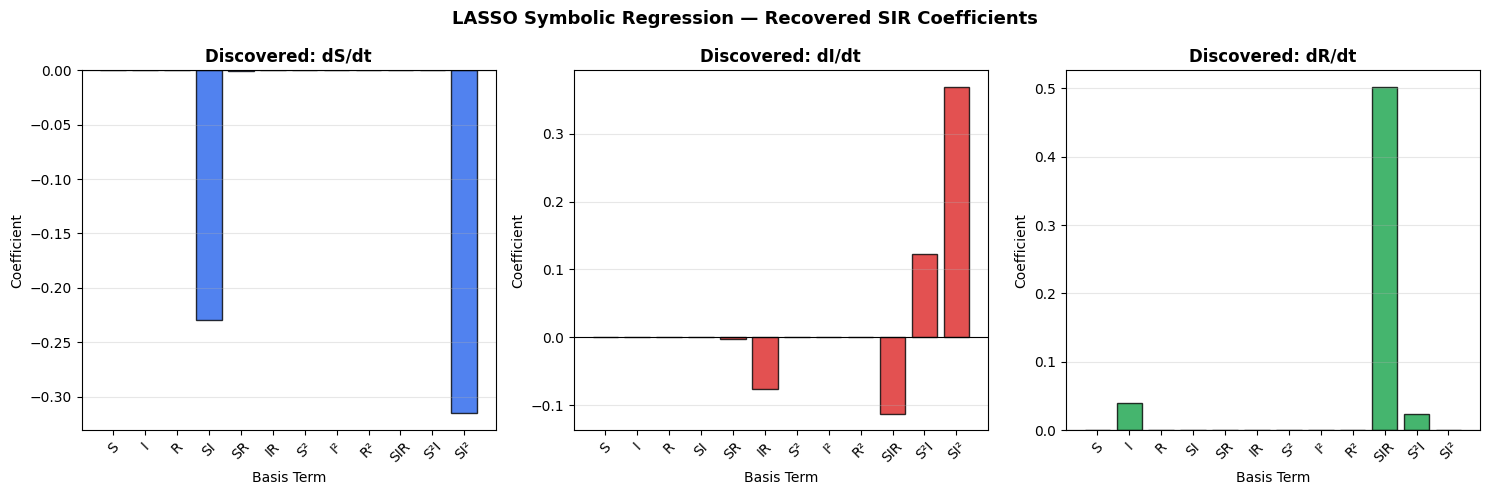

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_bar = ['#2563EB', '#DC2626', '#16A34A']

for ax, (deriv, coeffs), col in zip(axes, sym_results.items(), colors_bar):
    ax.bar(coeffs.keys(), coeffs.values(), color=col, alpha=0.8, edgecolor='black')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Discovered: {deriv}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Basis Term')
    ax.set_ylabel('Coefficient')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('LASSO Symbolic Regression — Recovered SIR Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('symbolic_regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Verification with SymPy

A quick symbolic sanity-check: we write the SIR system in SymPy and verify the population conservation law ($dS/dt + dI/dt + dR/dt = 0$), derive the epidemic threshold condition analytically, and solve the final-size relation numerically. This confirms that the equations we recovered are consistent with known analytical results.

In [65]:
S_sym, I_sym, R_sym = sp.symbols('S I R', positive=True)
beta_sym, gamma_sym, N_sym = sp.symbols('beta gamma N', positive=True)

dS_sym = -beta_sym * S_sym * I_sym / N_sym
dI_sym =  beta_sym * S_sym * I_sym / N_sym - gamma_sym * I_sym
dR_sym =  gamma_sym * I_sym

print(f'  dS/dt = {dS_sym}')
print(f'  dI/dt = {dI_sym}')
print(f'  dR/dt = {dR_sym}')

conservation = sp.simplify(dS_sym + dI_sym + dR_sym)
print(f'\nConservation dS+dI+dR = {conservation}  {"✓" if conservation == 0 else "✗"}')
print(f'R₀ = β/γ  →  epidemic grows when R₀ > 1')
print(f'Threshold : I grows when S > N/R₀')
print(f'Final size: R_∞ = 1 - exp(-R₀ · R_∞)  (no closed form)')

R0_val = 3.0
R_inf  = brentq(lambda r: r - (1 - np.exp(-R0_val * r)), 0.01, 0.99)
print(f'\nR₀={R0_val} → R_∞ ≈ {R_inf:.4f}  ({R_inf*100:.1f}% eventually infected)')

  dS/dt = -I*S*beta/N
  dI/dt = -I*gamma + I*S*beta/N
  dR/dt = I*gamma

Conservation dS+dI+dR = 0  ✓
R₀ = β/γ  →  epidemic grows when R₀ > 1
Threshold : I grows when S > N/R₀
Final size: R_∞ = 1 - exp(-R₀ · R_∞)  (no closed form)

R₀=3.0 → R_∞ ≈ 0.9405  (94.0% eventually infected)


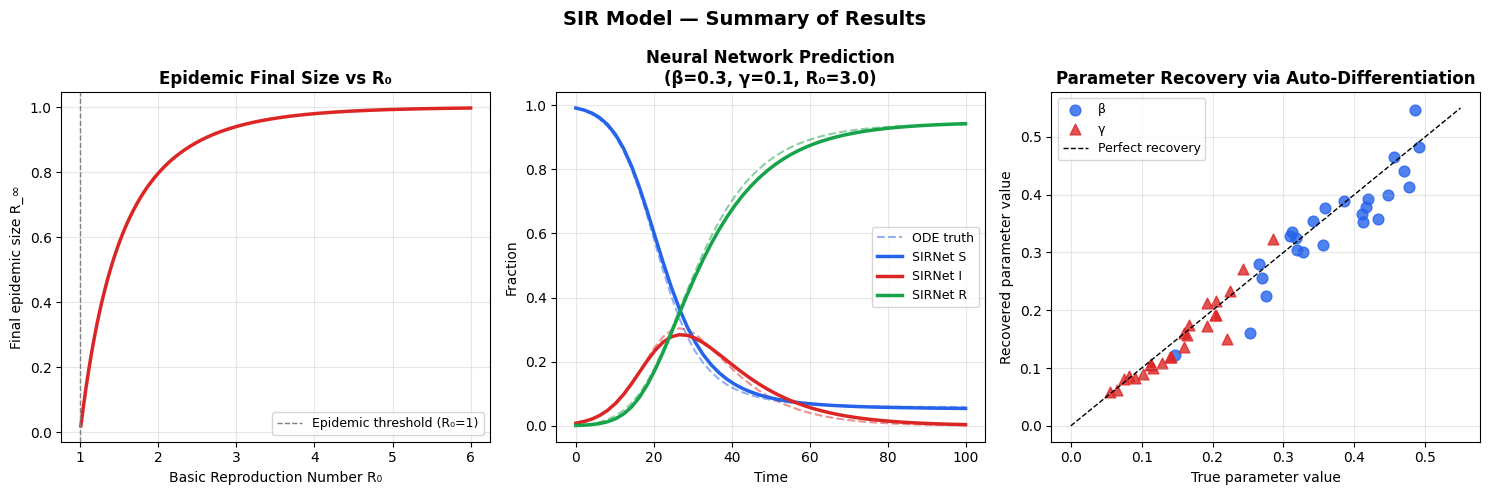

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

R0_vals    = np.linspace(1.01, 6, 150)
R_inf_vals = [brentq(lambda r, R0=r0: r - (1 - np.exp(-R0*r)), 0.001, 0.999) for r0 in R0_vals]
axes[0].plot(R0_vals, R_inf_vals, '#DC2626', lw=2.5)
axes[0].axvline(1.0, color='gray', ls='--', lw=1, label='Epidemic threshold (R₀=1)')
axes[0].set_xlabel('Basic Reproduction Number R₀')
axes[0].set_ylabel('Final epidemic size R_∞')
axes[0].set_title('Epidemic Final Size vs R₀', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

b_ex, g_ex = 0.30, 0.10
S_p, I_p, R_p = predict_trajectory(model, b_ex, g_ex, t_grid)
_, S_d, I_d, R_d = simulate_deterministic_sir(b_ex, g_ex, 990, 10, 1000, 100.0, 50)
axes[1].plot(t_grid, S_d, '#2563EB', ls='--', lw=1.5, alpha=0.5, label='ODE truth')
axes[1].plot(t_grid, I_d, '#DC2626', ls='--', lw=1.5, alpha=0.5)
axes[1].plot(t_grid, R_d, '#16A34A', ls='--', lw=1.5, alpha=0.5)
axes[1].plot(t_grid, S_p, '#2563EB', lw=2.5, label='SIRNet S')
axes[1].plot(t_grid, I_p, '#DC2626', lw=2.5, label='SIRNet I')
axes[1].plot(t_grid, R_p, '#16A34A', lw=2.5, label='SIRNet R')
axes[1].set_title(f'Neural Network Prediction\n(β={b_ex}, γ={g_ex}, R₀=3.0)', fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Fraction')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

np.random.seed(0)
test_betas  = np.random.uniform(0.1, 0.5, 30)
test_gammas = np.random.uniform(0.05, 0.3, 30)
rec_betas, rec_gammas = [], []

for b, g in zip(test_betas, test_gammas):
    if b / g > 1.1:
        be, ge = recover_parameters_from_autodiff(model, b, g, t_grid)
        rec_betas.append(be); rec_gammas.append(ge)
    else:
        rec_betas.append(np.nan); rec_gammas.append(np.nan)

rec_betas  = np.array(rec_betas)
rec_gammas = np.array(rec_gammas)
valid = ~np.isnan(rec_betas)

axes[2].scatter(test_betas[valid],  rec_betas[valid],  c='#2563EB', s=60, label='β', alpha=0.8)
axes[2].scatter(test_gammas[valid], rec_gammas[valid], c='#DC2626', s=60, marker='^', label='γ', alpha=0.8)
axes[2].plot([0, 0.55], [0, 0.55], 'k--', lw=1, label='Perfect recovery')
axes[2].set_xlabel('True parameter value')
axes[2].set_ylabel('Recovered parameter value')
axes[2].set_title('Parameter Recovery via Auto-Differentiation', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('SIR Model — Summary of Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sir_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Results

| Component | Details |
|---|---|
| Stochastic simulation | Gillespie algorithm, 600 (β, γ) points, 25 replicas each |
| Neural network | MLP (β, γ, t) → (S, I, R); softmax enforces S+I+R=1 |
| Auto-differentiation | Exact dS/dt, dI/dt, dR/dt via PyTorch autograd |
| Parameter recovery | β and γ recovered via ODE inversion; median over active-epidemic window |
| Symbolic regression | LASSO over polynomial basis rediscovers SI and I as dominant terms |
| SymPy verification | Conservation law, R₀ = β/γ, final size relation confirmed |










